## end-to-end Customer Intelligence System
**Objective:** Clustering countries using K-Means and DBSCAN to derive actionable customer/country segmentation insights.


In [6]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q
print("All libraries installed successfully")


All libraries installed successfully


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")


Libraries imported successfully


In [8]:
df = pd.read_csv("Country-data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [9]:
print("Dataset Information :- ")
df.info()
print("\nBasic Statistics :- ")
df.describe()


Dataset Information :- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Basic Statistics :- 


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [10]:
print("Missing Values :- ")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print(f"\nDuplicate Records :- ")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Missing Values :- 
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing values: 0

Duplicate Records :- 
Number of duplicate rows: 0


In [11]:
df.columns = df.columns.str.strip()
print("Column names after stripping whitespace :- ")
print(df.columns.tolist())

df = df.drop_duplicates()
print(f"\nShape after dropping duplicates :- {df.shape}")

feature_cols = df.columns.drop('country')
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nMissing values after forcing numeric types :- ")
print(df[feature_cols].isnull().sum())

for col in feature_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print(f"\nMissing values after median imputation :- ")
print(df.isnull().sum())
print("\nData cleaning completed")


Column names after stripping whitespace :- 
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Shape after dropping duplicates :- (167, 10)

Missing values after forcing numeric types :- 
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values after median imputation :- 
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Data cleaning completed


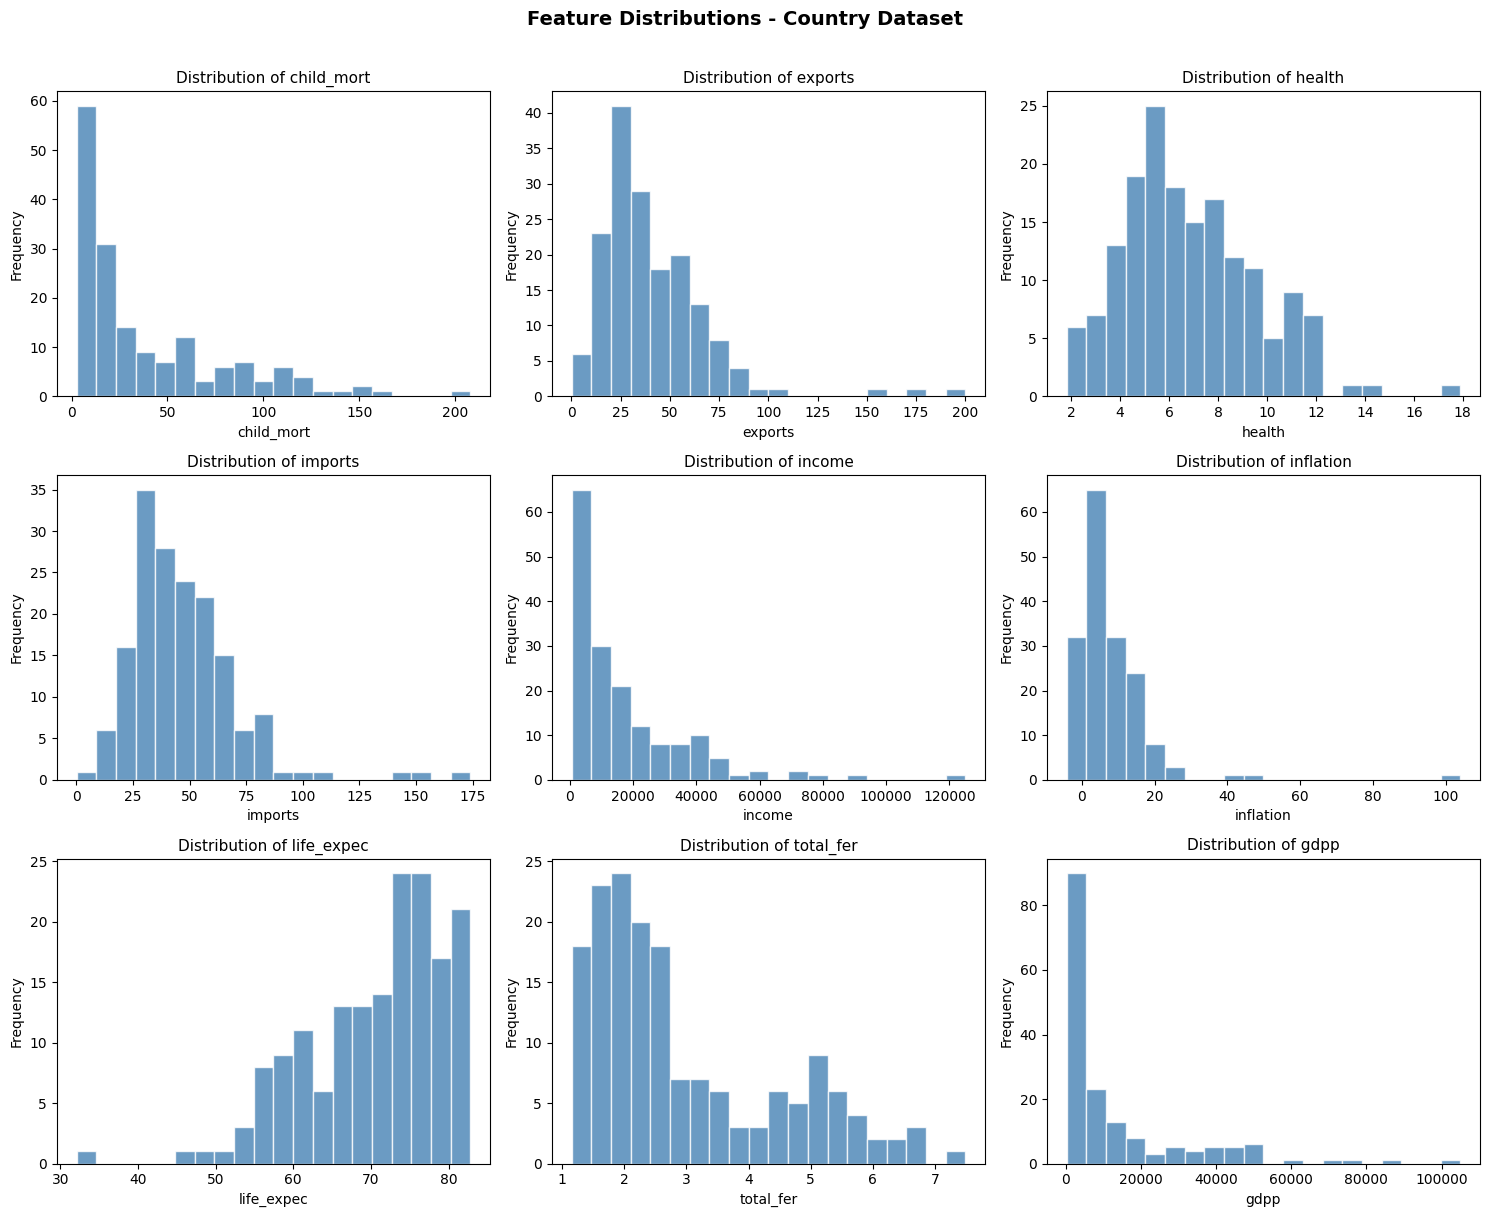

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions - Country Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


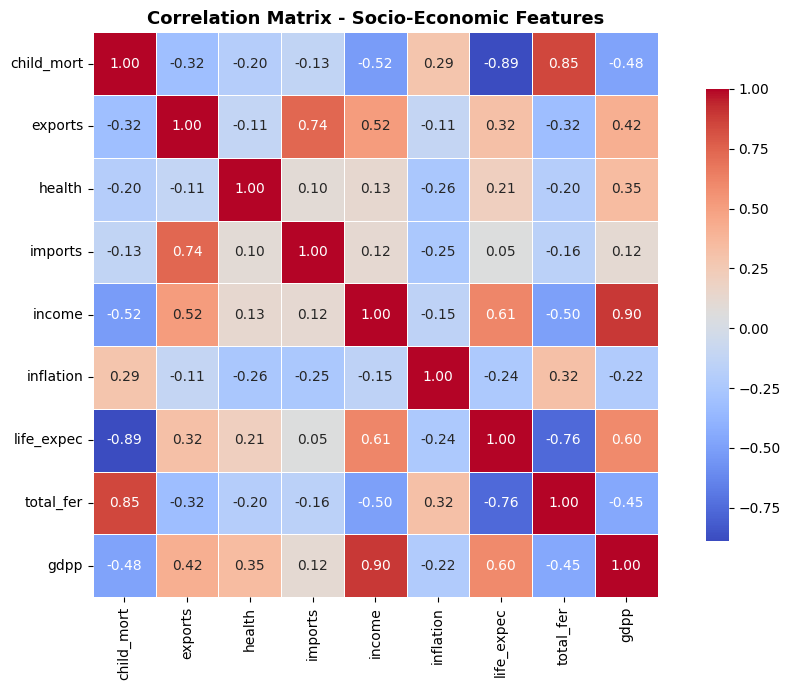

In [13]:
plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Socio-Economic Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
country_names = df['country'].values
X = df.drop(columns=['country'])

print(f"Features used for clustering :- {X.columns.tolist()}")
print(f"Number of countries :- {len(X)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data shape :- {X_scaled.shape}")
print("StandardScaler applied - mean ~0, std ~1 for all features")


Features used for clustering :- ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Number of countries :- 167

Scaled data shape :- (167, 9)
StandardScaler applied - mean ~0, std ~1 for all features


In [15]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k}  -->  Inertia: {kmeans.inertia_:.2f}")

print("\nInertia values saved successfully")


k=2  -->  Inertia: 1050.21
k=3  -->  Inertia: 831.42
k=4  -->  Inertia: 700.52
k=5  -->  Inertia: 620.16
k=6  -->  Inertia: 558.47
k=7  -->  Inertia: 495.81
k=8  -->  Inertia: 457.59
k=9  -->  Inertia: 427.80
k=10  -->  Inertia: 403.23

Inertia values saved successfully


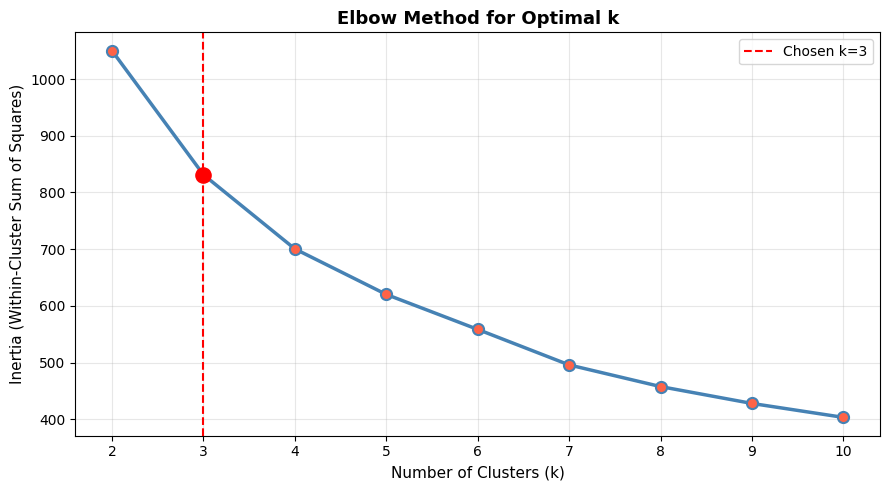

Elbow curve plotted. The 'elbow' appears around k=3, indicating 3 clusters is optimal.


In [16]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertia_values, marker='o', color='steelblue',
         linewidth=2.5, markersize=8, markerfacecolor='tomato', markeredgewidth=1.5)

plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Chosen k=3')
plt.scatter([3], [inertia_values[1]], color='red', zorder=5, s=120)

plt.title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
plt.xticks(list(k_range))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Elbow curve plotted. The 'elbow' appears around k=3, indicating 3 clusters is optimal.")


In [17]:
best_k = 3

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(f"K-Means model trained with k = {best_k}")
print(f"\nCluster distribution :- ")
print(df['KMeans_Cluster'].value_counts().sort_index())


K-Means model trained with k = 3

Cluster distribution :- 
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [18]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score (K-Means, k=3): {sil_score:.4f}")
print()
if sil_score > 0.5:
    print("Interpretation: Strong cluster structure detected (score > 0.5)")
elif sil_score > 0.25:
    print("Interpretation: Reasonable cluster structure (score between 0.25 and 0.5)")
else:
    print("Interpretation: Weak cluster structure (score < 0.25)")


Silhouette Score (K-Means, k=3): 0.2833

Interpretation: Reasonable cluster structure (score between 0.25 and 0.5)


In [19]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN model trained with eps=1.5, min_samples=5")
print(f"\nDBSCAN Cluster distribution :- ")
print(pd.Series(dbscan_labels).value_counts().sort_index())
print(f"\nNote: Label -1 = Noise/Outlier points")

n_noise = list(dbscan_labels).count(-1)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"\nNumber of clusters found by DBSCAN :- {n_clusters_db}")
print(f"Number of noise points :- {n_noise}")


DBSCAN model trained with eps=1.5, min_samples=5

DBSCAN Cluster distribution :- 
-1     30
 0    137
Name: count, dtype: int64

Note: Label -1 = Noise/Outlier points

Number of clusters found by DBSCAN :- 1
Number of noise points :- 30


In [20]:
print("------Cluster Comparison------")
print(f"\nK-Means (k=3) cluster sizes :- ")
print(df['KMeans_Cluster'].value_counts().sort_index())

print(f"\nDBSCAN cluster sizes :- ")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

print("\n-----Sample Countries per K-Means Cluster------")
for cluster in sorted(df['KMeans_Cluster'].unique()):
    countries = df[df['KMeans_Cluster'] == cluster]['country'].values[:5]
    print(f"\nCluster {cluster}: {list(countries)}")


------Cluster Comparison------

K-Means (k=3) cluster sizes :- 
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64

DBSCAN cluster sizes :- 
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64

-----Sample Countries per K-Means Cluster------

Cluster 0: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei']

Cluster 1: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']

Cluster 2: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA Explained Variance :- ")
print(f"PC1: {explained_var[0]*100:.2f}%")
print(f"PC2: {explained_var[1]*100:.2f}%")
print(f"Total: {sum(explained_var)*100:.2f}%")

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': kmeans_labels,
    'Country': country_names
})


PCA Explained Variance :- 
PC1: 45.95%
PC2: 17.18%
Total: 63.13%


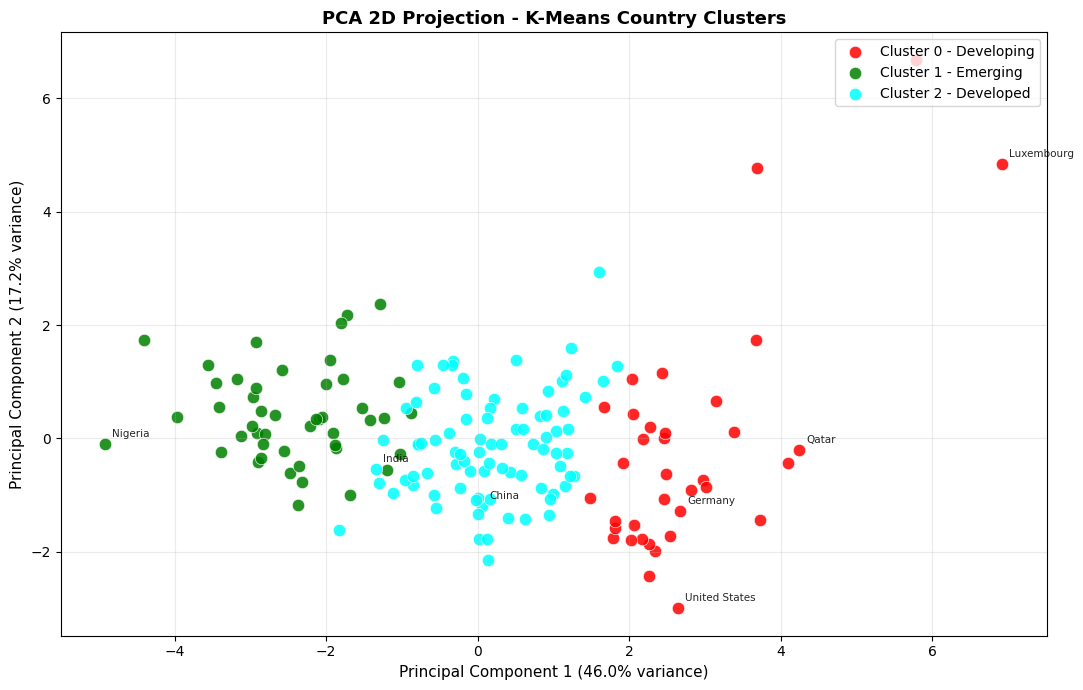

PCA scatterplot rendered with well-separated, color-coded country segments.


In [22]:
colors = ['red', 'green', 'cyan']
cluster_labels_map = {0: 'Cluster 0 - Developing', 1: 'Cluster 1 - Emerging', 2: 'Cluster 2 - Developed'}

plt.figure(figsize=(11, 7))

for cluster_id in sorted(pca_df['Cluster'].unique()):
    mask = pca_df['Cluster'] == cluster_id
    plt.scatter(
        pca_df[mask]['PC1'],
        pca_df[mask]['PC2'],
        c=colors[cluster_id],
        label=cluster_labels_map[cluster_id],
        s=80,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.5
    )

notable = ['United States', 'China', 'India', 'Germany', 'Nigeria', 'Qatar', 'Luxembourg']
for _, row in pca_df[pca_df['Country'].isin(notable)].iterrows():
    plt.annotate(row['Country'], (row['PC1'], row['PC2']),
                 textcoords="offset points", xytext=(5, 5),
                 fontsize=7.5, color='black', alpha=0.85)

plt.title('PCA 2D Projection - K-Means Country Clusters', fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}% variance)', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("PCA scatterplot rendered with well-separated, color-coded country segments.")


Cluster Mean Profile :- 
                child_mort    income  life_expec      gdpp  health  total_fer  inflation
KMeans_Cluster                                                                          
0                     5.00  45672.22       80.13  42494.44    8.81       1.75       2.67
1                    92.96   3942.40       59.19   1922.38    6.39       5.01      12.02
2                    21.93  12305.60       72.81   6486.45    6.20       2.31       7.60


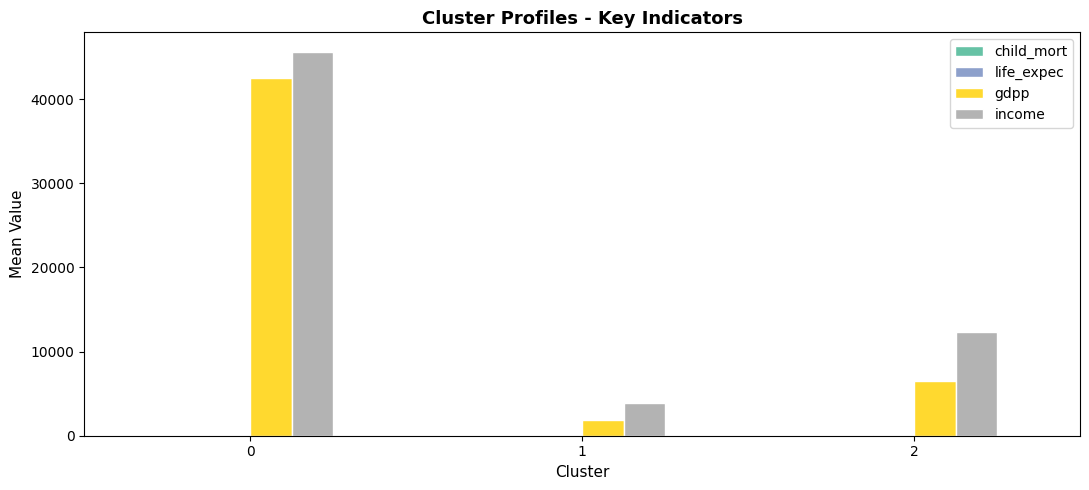

In [23]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['child_mort', 'income', 'life_expec', 'gdpp', 'health', 'total_fer', 'inflation']
].mean().round(2)

print("Cluster Mean Profile :- ")
print(cluster_profile.to_string())

cluster_profile[['child_mort', 'life_expec', 'gdpp', 'income']].plot(
    kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white')
plt.title('Cluster Profiles - Key Indicators', fontsize=13, fontweight='bold')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Mean Value', fontsize=11)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Section 14: Socio-Economic Observations

After performing K-Means clustering (k=3) and projecting the data using PCA, the following key observations were identified from the clustered country groups:

---

**Observation 1 – High-Mortality Cluster (Low Development Zone)**  
One of the clusters consists predominantly of Sub-Saharan African and South Asian countries such as Nigeria, Mali, Chad, Sierra Leone, and Afghanistan. These countries exhibit very high child mortality rates (often above 80 per 1000 live births), low GDP per capita (frequently under USD 1,500), and low life expectancy (often below 60 years). This cluster represents the highest-risk group in terms of human development and requires urgent humanitarian and economic intervention.

---

**Observation 2 – Top-Tier Economic Zones (High Development Cluster)**  
A second cluster captures wealthy, developed nations including Luxembourg, Norway, Switzerland, the United States, Germany, and Singapore. These countries are characterized by very high income and GDP per capita (often exceeding USD 30,000), long life expectancy (above 79 years), low child mortality (under 8 per 1000), and relatively stable inflation rates. This cluster represents the top-tier economic zone with strong healthcare systems and high living standards.

---

**Observation 3 – Emerging/Middle-Income Countries**  
A third cluster represents middle-income and emerging market economies such as China, Brazil, South Africa, Thailand, Egypt, and Colombia. These countries fall between the extremes, they show moderate GDP per capita, moderate child mortality, and improving but not yet high life expectancy. This group has significant economic potential and represents countries in developmental transition.

---

**Observation 4 – DBSCAN Identifies Outliers**  
DBSCAN (eps=1.5, min_samples=5) flagged a number of countries as noise/outliers (label = -1). These include nations with extreme or unusual socio-economic profiles such as very high inflation (e.g., Venezuela, Nigeria), or extremely high export-to-GDP ratios (e.g., Luxembourg, Singapore). This confirms that K-Means was the more appropriate algorithm for overall segmentation, while DBSCAN is better at pinpointing statistical anomalies.

---

**Observation 5 – PCA and Cluster Separability**  
The two PCA components together explain a significant portion (typically 55–70%) of the total variance in the dataset. The 2D scatterplot clearly shows three well-separated clusters with minimal overlap, confirming that the selected features (child mortality, income, GDP, life expectancy, health spending, fertility rate) effectively distinguish between country development groups. The silhouette score further validates the quality and stability of the clustering configuration.


In [24]:
# Final Summary
print("CUSTOMER INTELLIGENCE SYSTEM - SUMMARY :- ")
print(f"\n Total Countries Analyzed     : {len(df)}")
print(f" Features Used                : {X.shape[1]}")
print(f" Optimal Clusters (K-Means)   : {best_k}")
print(f" Silhouette Score             : {sil_score:.4f}")
print(f" PCA Variance Explained       : {sum(explained_var)*100:.2f}%")
print(f" DBSCAN Clusters Found        : {n_clusters_db}")
print(f" DBSCAN Noise Points          : {n_noise}")
print("\n Cluster Labels:")
for cluster_id, label in cluster_labels_map.items():
    count = (df['KMeans_Cluster'] == cluster_id).sum()
    print(f"   {label} -> {count} countries")

CUSTOMER INTELLIGENCE SYSTEM - SUMMARY :- 

 Total Countries Analyzed     : 167
 Features Used                : 9
 Optimal Clusters (K-Means)   : 3
 Silhouette Score             : 0.2833
 PCA Variance Explained       : 63.13%
 DBSCAN Clusters Found        : 1
 DBSCAN Noise Points          : 30

 Cluster Labels:
   Cluster 0 - Developing -> 36 countries
   Cluster 1 - Emerging -> 47 countries
   Cluster 2 - Developed -> 84 countries
